# Notebook 05 — Preparación de Datos y Modelado ML

**Proyecto:** Sistema de Predicción y Clasificación de la Desnutrición en niños menores de cinco años  
**Fase CRISP-DM:** 3 (Preparación) + 4 (Modelado)  
**Dataset:** `dataset_ml.csv` (generado por notebook 03)  
**Variable objetivo:** `clas_peso`

---
## Contenido
### Parte 1 — Preparación de datos
1. Carga e inspección
2. Ingeniería de features — selección y descarte justificado
3. Codificación de variables categóricas
4. Imputación de nulos residuales
5. Escalado — RobustScaler selectivo
6. División train/test estratificada
7. Balanceo de clases — SMOTE

### Parte 2 — Modelado
8. Entrenamiento de modelos
9. Comparativa de métricas
10. Matriz de confusión del mejor modelo
11. Feature importance
12. Conclusiones y modelo seleccionado

---
# PARTE 1 — Preparación de datos

## 1. Carga e inspección

In [1]:
import sys
!{sys.executable} -m pip install imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score)
from imblearn.over_sampling import SMOTE

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3})

CLASES     = ['Desnut. severa', 'Desnut. moderada', 'Normal bajo',
              'Normal', 'Sobrepeso', 'Obesidad']
COLORES    = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#2980b9', '#8e44ad']

df_raw = pd.read_csv('../data/processed/dataset_ml.csv')
print(f'Shape original : {df_raw.shape}')
print(f'Columnas       : {list(df_raw.columns)}')
print(f'\nclas_peso distribución:')
print(df_raw['clas_peso'].value_counts().sort_index())

Shape original : (2448, 53)
Columnas       : ['anio', 'edad_', 'uni_med_', 'sexo_', 'nacionali_', 'per_etn_', 'estrato_', 'cod_pais_o', 'cod_dpto_o', 'cod_mun_o', 'area_', 'cod_pais_r', 'cod_dpto_r', 'cod_mun_r', 'ndep_resi', 'nmun_resi', 'tip_ss_', 'niv_educat', 'menores', 'gp_desplaz', 'gp_migrant', 'gp_indigen', 'gp_pobicbf', 'gp_mad_com', 'gp_vic_vio', 'gp_gestan', 'ocupacion_', 'peso_nac', 'talla_nac', 'edad_ges', 't_lechem', 'e_complem', 'crec_dllo', 'esq_vac', 'carne_vac', 'peso_act', 'talla_act', 'per_braqui', 'imc', 'clas_peso', 'clas_talla', 'edema', 'delgadez', 'palidez', 'piel_rese', 'hiperpigm', 'cambios_cabello', 'ruta_atenc', 'tipo_manej', 'pac_hos_', 'con_fin_', 'tip_cas_', 'fuente_']

clas_peso distribución:
clas_peso
1.0     379
2.0    1730
3.0     133
4.0     167
5.0      24
6.0       6
Name: count, dtype: int64


## 2. Ingeniería de features — selección y descarte justificado

Se parte de las 53 columnas del `dataset_ml.csv` y se reduce a un set limpio de **26 features**,
eliminando columnas por razones metodológicas documentadas.

In [2]:
# ── Eliminar clas_peso nulos (9 registros) ────────────────────────────────
df = df_raw.dropna(subset=['clas_peso']).copy()
df['clas_peso'] = df['clas_peso'].astype(int)

# ── Crear edad_meses (más informativa que edad_ + uni_med_ por separado) ──
df['edad_meses'] = df.apply(
    lambda r: r['edad_'] * 12 if r['uni_med_'] == 1 else r['edad_'], axis=1
)

# ── Columnas a eliminar y justificación ───────────────────────────────────
DESCARTAR = {
    'talla_act'   : 'Multicolinealidad con peso_act (r=0.95) — aporta información redundante',
    'talla_nac'   : '61% nulos — no es imputable de forma fiable',
    'anio'        : 'Variable temporal administrativa, no feature del paciente',
    'edad_'       : 'Reemplazada por edad_meses (más precisa)',
    'uni_med_'    : 'Solo necesaria para calcular edad_meses, ya creada',
    'nacionali_'  : 'Redundante con cod_pais_o y per_etn_',
    'cod_pais_o'  : 'Redundante con per_etn_ y area_',
    'cod_pais_r'  : 'Redundante',
    'cod_mun_o'   : 'Alta cardinalidad (36 municipios) — usar departamento',
    'cod_mun_r'   : 'Alta cardinalidad (39 municipios)',
    'nmun_resi'   : 'Alta cardinalidad (44 valores) — texto libre',
    'cod_dpto_r'  : 'Redundante con cod_dpto_o',
    'ndep_resi'   : 'Texto — reemplazado por cod_dpto_o codificado',
    'tip_ss_'     : '97% del mismo valor (S=subsidiado) — sin variabilidad',
    'gp_desplaz'  : 'Solo 9 casos positivos — sin variabilidad estadística',
    'gp_migrant'  : 'Solo 10 casos positivos',
    'gp_indigen'  : 'Solo 1 caso positivo',
    'gp_vic_vio'  : 'Solo 1 caso positivo',
    'gp_mad_com'  : 'Todos el mismo valor (2) — sin variabilidad',
    'gp_gestan'   : 'Todos el mismo valor (2) — sin variabilidad',
    'tipo_manej'  : '178 nulos + redundante con ruta_atenc',
    'con_fin_'    : 'Variable de resultado (qué pasó después) — no disponible al momento de predecir',
    'pac_hos_'    : 'Variable de resultado — no disponible al momento de predecir',
    'fuente_'     : 'Variable administrativa',
    'tip_cas_'    : 'Variable administrativa',
}

print('Columnas descartadas y justificación:')
for col, razon in DESCARTAR.items():
    estado = '✅ en dataset' if col in df.columns else '— no presente'
    print(f'  {col:20s}: {razon}')

# ── Features finales ──────────────────────────────────────────────────────
FEATURES = [
    # Demográficas
    'edad_meses',       # Edad en meses (calculada)
    'per_etn_',         # Pertenencia étnica (1=Indígena...6=Otro)
    'estrato_',         # Estrato socioeconómico
    # Geográficas
    'area_',            # 1=Cabecera, 2=Centro poblado, 3=Rural disperso
    'cod_dpto_o',       # Departamento de origen (codificado)
    # Socioeconómicas
    'niv_educat',       # Nivel educativo de la madre
    'menores',          # Número de menores en el hogar
    'gp_pobicbf',       # Beneficiario ICBF (1=Sí, 2=No)
    # Clínicas — antecedentes
    'peso_nac',         # Peso al nacer (g)
    'edad_ges',         # Edad gestacional (semanas)
    # Clínicas — actuales (sin zscore por leakage, sin talla_act por multicolinealidad)
    'peso_act',         # Peso actual (kg)
    'per_braqui',       # Perímetro braquial (cm)
    'imc',              # IMC actual (kg/m²)
    # Maternales / seguimiento
    't_lechem',         # Tiempo de lactancia materna (meses)
    'e_complem',        # Edad inicio alimentación complementaria (meses)
    'crec_dllo',        # Seguimiento C&D (1=Con, 2=Sin)
    'esq_vac',          # Esquema de vacunación (1=Completo, 2=Incompleto, 3=Sin)
    'carne_vac',        # Tiene carné de vacunación (1=Sí, 2=No)
    # Hallazgos clínicos (signos físicos observables)
    'edema',            # 1=Sí, 2=No
    'delgadez',         # 1=Sí, 2=No
    'palidez',          # 1=Sí, 2=No
    'piel_rese',        # Piel reseca 1=Sí, 2=No
    'hiperpigm',        # Hiperpigmentación 1=Sí, 2=No
    'cambios_cabello',  # Cambios en cabello 1=Sí, 2=No
    # Atención
    'ruta_atenc',       # 1=Urgencias, 2=Consulta externa
]

# Verificar que todos existen
faltantes = [f for f in FEATURES if f not in df.columns]
print(f'\nFeatures faltantes en el dataset: {faltantes if faltantes else "Ninguno ✅"}')
print(f'Total features seleccionados: {len(FEATURES)}')

Columnas descartadas y justificación:
  talla_act           : Multicolinealidad con peso_act (r=0.95) — aporta información redundante
  talla_nac           : 61% nulos — no es imputable de forma fiable
  anio                : Variable temporal administrativa, no feature del paciente
  edad_               : Reemplazada por edad_meses (más precisa)
  uni_med_            : Solo necesaria para calcular edad_meses, ya creada
  nacionali_          : Redundante con cod_pais_o y per_etn_
  cod_pais_o          : Redundante con per_etn_ y area_
  cod_pais_r          : Redundante
  cod_mun_o           : Alta cardinalidad (36 municipios) — usar departamento
  cod_mun_r           : Alta cardinalidad (39 municipios)
  nmun_resi           : Alta cardinalidad (44 valores) — texto libre
  cod_dpto_r          : Redundante con cod_dpto_o
  ndep_resi           : Texto — reemplazado por cod_dpto_o codificado
  tip_ss_             : 97% del mismo valor (S=subsidiado) — sin variabilidad
  gp_desplaz         

## 3. Codificación de variables categóricas

- **`cod_dpto_o`** — viene como string (`'20'`, `'44'`, `'D0'`). Se aplica **Label Encoding**
  porque es ordinal implícito y tiene baja cardinalidad (9 valores únicos).
- El resto de variables categóricas ya son numéricas en el dataset.

In [3]:
df_model = df[FEATURES + ['clas_peso']].copy()

# Label Encoding para cod_dpto_o (string → entero)
le_dpto = LabelEncoder()
df_model['cod_dpto_o'] = le_dpto.fit_transform(df_model['cod_dpto_o'].astype(str))

print('Codificación cod_dpto_o:')
for codigo, etiqueta in zip(le_dpto.classes_, le_dpto.transform(le_dpto.classes_)):
    print(f'  {codigo} → {etiqueta}')

print(f'\nDtypes resultantes:')
print(df_model.dtypes.to_string())

Codificación cod_dpto_o:
  11 → 0
  15 → 1
  20 → 2
  25 → 3
  44 → 4
  47 → 5
  52 → 6
  68 → 7
  D0 → 8

Dtypes resultantes:
edad_meses           int64
per_etn_             int64
estrato_             int64
area_                int64
cod_dpto_o           int64
niv_educat         float64
menores            float64
gp_pobicbf         float64
peso_nac           float64
edad_ges           float64
peso_act           float64
per_braqui         float64
imc                float64
t_lechem           float64
e_complem          float64
crec_dllo            int64
esq_vac              int64
carne_vac            int64
edema                int64
delgadez             int64
palidez              int64
piel_rese            int64
hiperpigm            int64
cambios_cabello      int64
ruta_atenc           int64
clas_peso            int64


## 4. Imputación de nulos residuales

Solo 3 features tienen nulos residuales tras el ETL:
- `niv_educat` (33 nulos) → mediana
- `gp_pobicbf` (2 nulos) → valor por defecto 2 (No)
- `per_braqui` (227 nulos, ~9%) → mediana por `clas_peso` (imputación estratificada)

In [4]:
print('Nulos antes de imputación:')
nulos = df_model.isnull().sum()
print(nulos[nulos > 0].to_string())

# niv_educat: mediana global
med_edu = df_model['niv_educat'].median()
df_model['niv_educat'] = df_model['niv_educat'].fillna(med_edu)
print(f'\nniv_educat: imputado con mediana = {med_edu}')

# gp_pobicbf: 2 = No (valor por defecto)
df_model['gp_pobicbf'] = df_model['gp_pobicbf'].fillna(2)
print('gp_pobicbf: 2 nulos → 2 (No)')

# menores: mediana global
df_model['menores'] = df_model['menores'].fillna(df_model['menores'].median())

# per_braqui: mediana por clas_peso (imputación estratificada)
df_model['per_braqui'] = df_model.groupby('clas_peso')['per_braqui'].transform(
    lambda x: x.fillna(x.median())
)
df_model['per_braqui'] = df_model['per_braqui'].fillna(df_model['per_braqui'].median())
print(f'per_braqui: imputado con mediana estratificada por clas_peso')

print(f'\nNulos después de imputación: {df_model.isnull().sum().sum()} ✅')

Nulos antes de imputación:
niv_educat     33
gp_pobicbf      2
per_braqui    227

niv_educat: imputado con mediana = 3.0
gp_pobicbf: 2 nulos → 2 (No)
per_braqui: imputado con mediana estratificada por clas_peso

Nulos después de imputación: 0 ✅


## 5. Escalado — RobustScaler selectivo

Se aplica **RobustScaler** solo a las variables que resultaron NO normales en las pruebas
de normalidad del notebook 04 (sección 12). Las variables ya normales no se tocan.

**¿Por qué RobustScaler y no StandardScaler?**  
Porque usa la mediana y el rango intercuartílico en lugar de la media y desviación estándar,
lo que lo hace resistente a los outliers que vimos en los boxplots del notebook 04.

In [5]:
# Variables NO normales → escalar
COLS_ESCALAR = ['peso_act', 'per_braqui', 't_lechem', 'menores',
                'peso_nac', 'edad_meses', 'imc', 'edad_ges', 'e_complem']

X = df_model[FEATURES].copy()
y = df_model['clas_peso'].copy()

scaler = RobustScaler()
X[COLS_ESCALAR] = scaler.fit_transform(X[COLS_ESCALAR])

print('RobustScaler aplicado a:')
for col in COLS_ESCALAR:
    print(f'  {col}')
print(f'\nShape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nEstadísticas post-escalado (columnas escaladas):')
print(X[COLS_ESCALAR].describe().round(3).to_string())

RobustScaler aplicado a:
  peso_act
  per_braqui
  t_lechem
  menores
  peso_nac
  edad_meses
  imc
  edad_ges
  e_complem

Shape X: (2439, 25)
Shape y: (2439,)

Estadísticas post-escalado (columnas escaladas):
       peso_act  per_braqui  t_lechem   menores  peso_nac  edad_meses       imc  edad_ges  e_complem
count  2439.000    2439.000  2439.000  2439.000  2439.000    2439.000  2439.000  2439.000   2439.000
mean      0.036       0.069     0.306     0.310    -0.720       0.347     0.052    -0.538     -0.255
std       0.953       0.843     1.128     1.133     3.143       0.874     1.188     1.668      3.795
min      -2.273      -4.429    -1.333    -1.000   -18.048      -0.846    -3.209   -17.000     -6.000
25%      -0.500      -0.429    -0.333     0.000    -1.000      -0.077    -0.482    -1.000      0.000
50%       0.000       0.000     0.000     0.000     0.000       0.000     0.000     0.000      0.000
75%       0.500       0.571     0.667     1.000     0.000       0.923     0.518   

## 6. División train/test estratificada

Se usa **stratify=y** para garantizar que la proporción de cada clase de desnutrición
sea la misma en train y test. Sin esto, las clases minoritarias (Sobrepeso, Obesidad)
podrían quedar subrepresentadas en el conjunto de prueba.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nDistribución de clases en train:')
print(y_train.value_counts().sort_index().rename('Train'))
print(f'\nDistribución de clases en test:')
print(y_test.value_counts().sort_index().rename('Test'))

Train : 1,951 registros (80%)
Test  : 488 registros (20%)

Distribución de clases en train:
clas_peso
1     303
2    1384
3     106
4     134
5      19
6       5
Name: Train, dtype: int64

Distribución de clases en test:
clas_peso
1     76
2    346
3     27
4     33
5      5
6      1
Name: Test, dtype: int64


## 7. Balanceo de clases — SMOTE

El dataset tiene un desbalance severo: >85% de los casos son desnutrición.
Las clases Sobrepeso (24 casos) y Obesidad (6 casos) son muy minoritarias.

**SMOTE** (Synthetic Minority Over-sampling Technique) genera ejemplos sintéticos
de las clases minoritarias interpolando entre casos reales existentes.

**Importante:** SMOTE se aplica **solo al conjunto de entrenamiento**, nunca al test.
Aplicarlo al test contaminaría la evaluación.

Distribución ANTES de SMOTE (train):
clas_peso
1     303
2    1384
3     106
4     134
5      19
6       5

Distribución DESPUÉS de SMOTE (train):
clas_peso
1    1384
2    1384
3    1384
4    1384
5    1384
6    1384

Tamaño train original : 1,951
Tamaño train con SMOTE: 8,304


  File "c:\Users\yorie\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\yorie\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\yorie\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\yorie\anaconda3\Lib\subprocess.

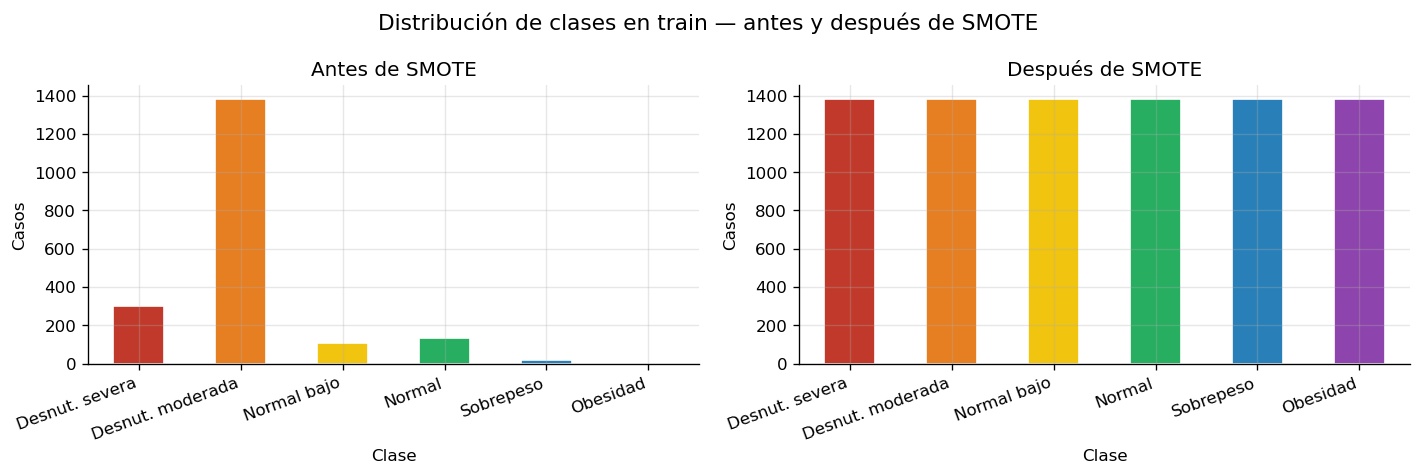

In [7]:
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Distribución ANTES de SMOTE (train):')
print(y_train.value_counts().sort_index().to_string())
print(f'\nDistribución DESPUÉS de SMOTE (train):')
print(pd.Series(y_train_sm).value_counts().sort_index().to_string())
print(f'\nTamaño train original : {len(y_train):,}')
print(f'Tamaño train con SMOTE: {len(y_train_sm):,}')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_train.value_counts().sort_index().plot(kind='bar', ax=axes[0], color=COLORES, edgecolor='white')
axes[0].set_title('Antes de SMOTE', fontsize=12)
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Casos')
axes[0].set_xticklabels(CLASES, rotation=20, ha='right')

pd.Series(y_train_sm).value_counts().sort_index().plot(kind='bar', ax=axes[1], color=COLORES, edgecolor='white')
axes[1].set_title('Después de SMOTE', fontsize=12)
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Casos')
axes[1].set_xticklabels(CLASES, rotation=20, ha='right')
plt.suptitle('Distribución de clases en train — antes y después de SMOTE', fontsize=13)
plt.tight_layout()
plt.show()

---
# PARTE 2 — Modelado

## 8. Entrenamiento de modelos

Se entrenan 4 modelos con diferentes enfoques:

| Modelo | Tipo | Razón de inclusión |
|---|---|---|
| Logistic Regression | Lineal | Baseline — modelo simple de referencia |
| Random Forest | Ensamble de árboles | Robusto, maneja bien variables mixtas |
| Gradient Boosting | Ensamble boosting | Generalmente el mejor en datos tabulares |
| SVM | Kernel | Efectivo en espacios de alta dimensión |

Todos se entrenan con los datos balanceados por SMOTE.

In [8]:
MODELOS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42, C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=None, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1,
        max_depth=4, random_state=42
    ),
    'SVM': SVC(
        kernel='rbf', class_weight='balanced',
        C=10, gamma='scale', probability=True, random_state=42
    ),
}

modelos_entrenados = {}
for nombre, modelo in MODELOS.items():
    print(f'Entrenando {nombre}...', end=' ')
    modelo.fit(X_train_sm, y_train_sm)
    modelos_entrenados[nombre] = modelo
    print('✅')

print('\nTodos los modelos entrenados.')

Entrenando Logistic Regression... ✅
Entrenando Random Forest... ✅
Entrenando Gradient Boosting... ✅
Entrenando SVM... ✅

Todos los modelos entrenados.


## 9. Comparativa de métricas

**¿Qué métricas usar y por qué?**

- **Accuracy**: % de predicciones correctas. Engañosa con clases desbalanceadas
- **F1-weighted**: promedio de F1 ponderado por frecuencia de clase. La más importante aquí
- **F1-macro**: promedio de F1 sin ponderar. Penaliza más los errores en clases pequeñas
- **Recall-macro**: qué % de cada clase detecta correctamente. Crítico en salud pública

En contexto clínico, **el error más costoso es NO detectar desnutrición severa** (falso negativo).
Por eso el Recall de la clase 1 (Desnutrición severa) recibe atención especial.

Comparativa de modelos:
             Modelo  Accuracy  F1-weighted  F1-macro  F1-Desnut.severa  Recall-D.severa
  Gradient Boosting    0.8648       0.8645    0.7420            0.7183           0.6711
      Random Forest    0.8627       0.8611    0.7751            0.6853           0.6447
                SVM    0.8402       0.8391    0.5692            0.6351           0.6184
Logistic Regression    0.7889       0.7981    0.4713            0.6463           0.6974


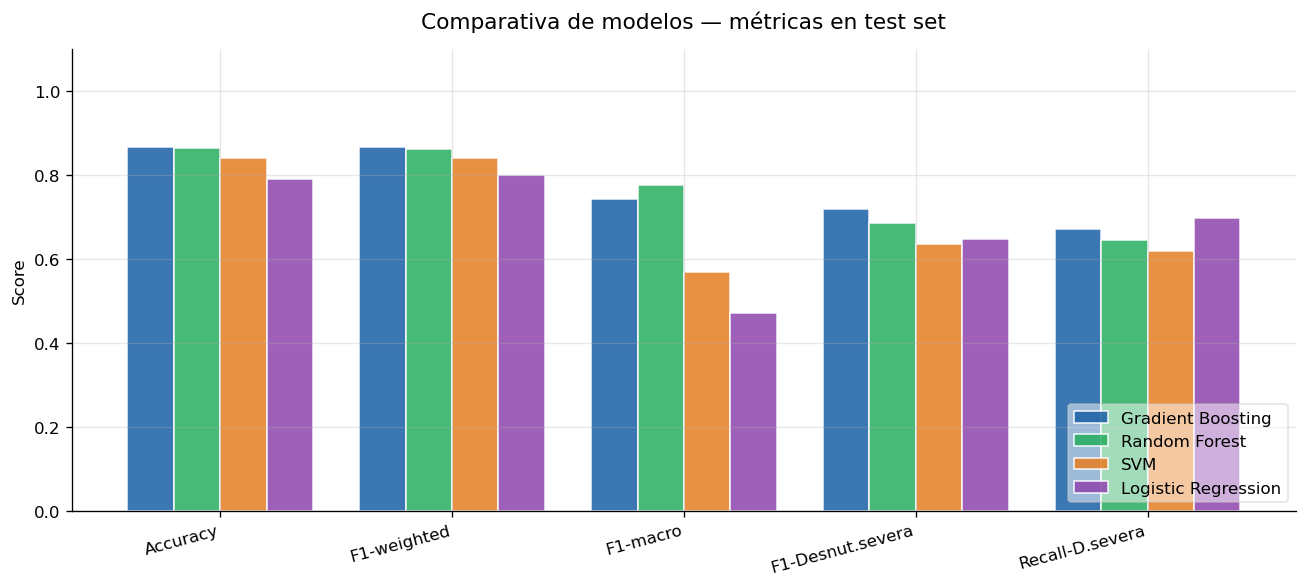

In [9]:
resultados = []
predicciones = {}

for nombre, modelo in modelos_entrenados.items():
    y_pred = modelo.predict(X_test)
    predicciones[nombre] = y_pred

    acc   = (y_pred == y_test).mean()
    f1_w  = f1_score(y_test, y_pred, average='weighted')
    f1_m  = f1_score(y_test, y_pred, average='macro')
    f1_c1 = f1_score(y_test, y_pred, labels=[1], average='macro')  # Desnut. severa
    rec_c1 = (y_pred[y_test == 1] == 1).mean() if (y_test == 1).sum() > 0 else 0

    resultados.append({
        'Modelo'          : nombre,
        'Accuracy'        : round(acc,   4),
        'F1-weighted'     : round(f1_w,  4),
        'F1-macro'        : round(f1_m,  4),
        'F1-Desnut.severa': round(f1_c1, 4),
        'Recall-D.severa' : round(rec_c1,4),
    })

df_resultados = pd.DataFrame(resultados).sort_values('F1-weighted', ascending=False)
print('Comparativa de modelos:')
print(df_resultados.to_string(index=False))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(11, 5))
metricas = ['Accuracy', 'F1-weighted', 'F1-macro', 'F1-Desnut.severa', 'Recall-D.severa']
x = np.arange(len(metricas))
width = 0.2
colores_mod = ['#185fa5', '#27ae60', '#e67e22', '#8e44ad']

for i, (_, row) in enumerate(df_resultados.iterrows()):
    vals = [row[m] for m in metricas]
    ax.bar(x + i * width, vals, width, label=row['Modelo'],
           color=colores_mod[i], edgecolor='white', alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metricas, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Comparativa de modelos — métricas en test set', fontsize=13, pad=12)
ax.legend(loc='lower right', framealpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# Reporte detallado de cada modelo
for nombre, y_pred in predicciones.items():
    print(f'\n{"="*55}')
    print(f'  {nombre}')
    print(f'{"="*55}')
    print(classification_report(y_test, y_pred, target_names=CLASES, zero_division=0))


  Logistic Regression
                  precision    recall  f1-score   support

  Desnut. severa       0.60      0.70      0.65        76
Desnut. moderada       0.93      0.86      0.89       346
     Normal bajo       0.41      0.59      0.48        27
          Normal       0.57      0.52      0.54        33
       Sobrepeso       0.20      0.40      0.27         5
        Obesidad       0.00      0.00      0.00         1

        accuracy                           0.79       488
       macro avg       0.45      0.51      0.47       488
    weighted avg       0.81      0.79      0.80       488


  Random Forest
                  precision    recall  f1-score   support

  Desnut. severa       0.73      0.64      0.69        76
Desnut. moderada       0.91      0.92      0.92       346
     Normal bajo       0.62      0.74      0.68        27
          Normal       0.83      0.91      0.87        33
       Sobrepeso       0.67      0.40      0.50         5
        Obesidad       1.00 

## 10. Matriz de confusión del mejor modelo

**¿Cómo leer la matriz?**  
- Diagonal principal (verde) → predicciones correctas  
- Fuera de la diagonal → errores  
- Fila = clase real | Columna = clase predicha  

El error más crítico en este contexto es confundir **Desnutrición severa** con **Desnutrición moderada**
(o viceversa) — son clases vecinas y tienen tratamiento diferente.

Mejor modelo: Gradient Boosting
F1-weighted : 0.8645


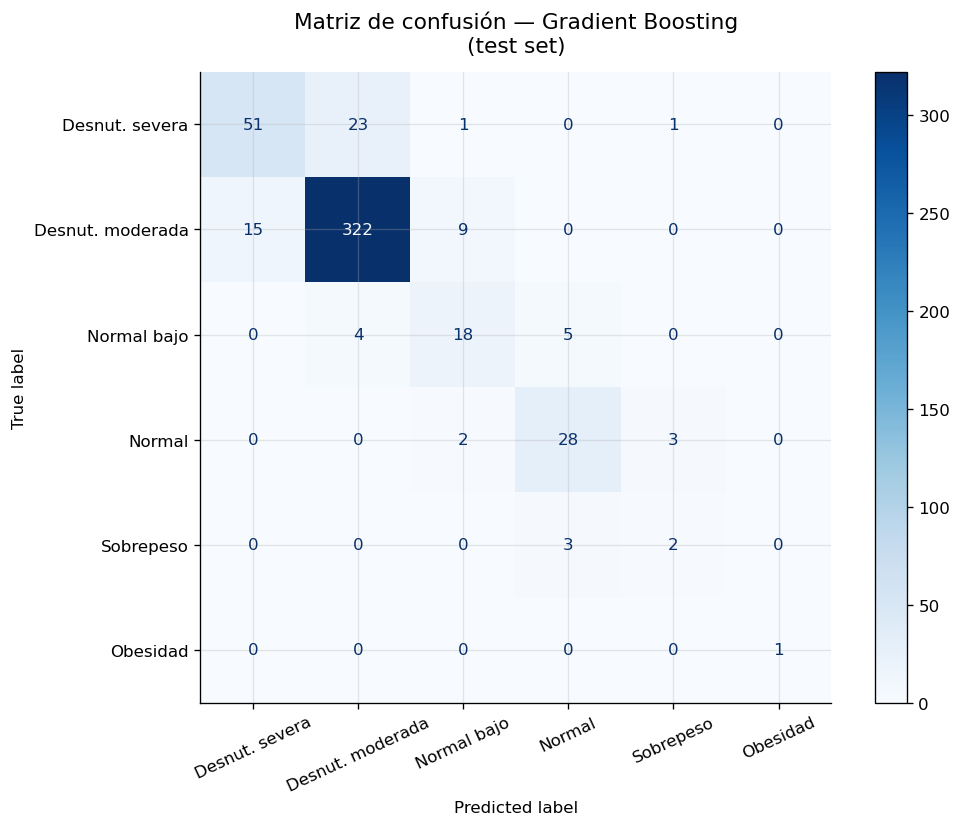


Análisis de errores críticos (Desnutrición severa):
  Casos reales en test     : 76
  Correctamente detectados : 51 (67.1%)
  No detectados (FN)       : 25 (32.9%)


In [11]:
# Identificar el mejor modelo por F1-weighted
mejor_nombre = df_resultados.iloc[0]['Modelo']
y_pred_mejor = predicciones[mejor_nombre]

print(f'Mejor modelo: {mejor_nombre}')
print(f'F1-weighted : {df_resultados.iloc[0]["F1-weighted"]:.4f}')

cm = confusion_matrix(y_test, y_pred_mejor)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASES)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=25)
ax.set_title(f'Matriz de confusión — {mejor_nombre}\n(test set)',
             fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Análisis de errores críticos
total_severos = (y_test == 1).sum()
detectados    = cm[0, 0]
print(f'\nAnálisis de errores críticos (Desnutrición severa):')
print(f'  Casos reales en test     : {total_severos}')
print(f'  Correctamente detectados : {detectados} ({detectados/total_severos*100:.1f}%)')
print(f'  No detectados (FN)       : {total_severos - detectados} ({(total_severos-detectados)/total_severos*100:.1f}%)')

## 11. Feature importance

**¿Qué tan importante fue cada variable para el modelo?**  
Muestra qué variables el modelo aprendió a usar más para tomar sus decisiones.  
Permite validar que el modelo está usando variables clínicamente coherentes.

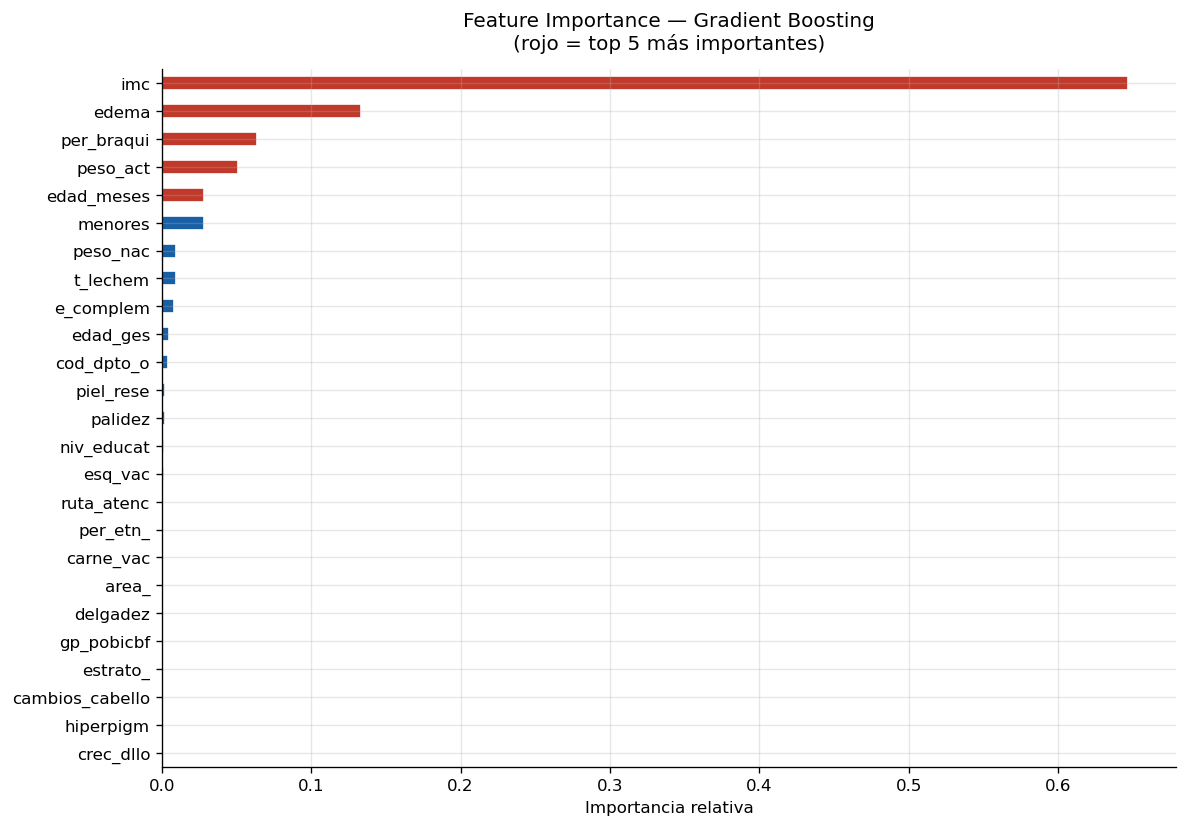

Feature importance ordenada:
imc                0.6466
edema              0.1332
per_braqui         0.0638
peso_act           0.0509
edad_meses         0.0285
menores            0.0279
peso_nac           0.0096
t_lechem           0.0092
e_complem          0.0082
edad_ges           0.0051
cod_dpto_o         0.0040
piel_rese          0.0024
palidez            0.0019
niv_educat         0.0018
esq_vac            0.0012
ruta_atenc         0.0010
per_etn_           0.0008
carne_vac          0.0007
area_              0.0007
delgadez           0.0007
gp_pobicbf         0.0006
estrato_           0.0004
cambios_cabello    0.0003
hiperpigm          0.0002
crec_dllo          0.0002


In [12]:
# Feature importance según el tipo de modelo
modelo_mejor = modelos_entrenados[mejor_nombre]

if hasattr(modelo_mejor, 'feature_importances_'):
    importancias = pd.Series(modelo_mejor.feature_importances_, index=FEATURES)
    titulo = f'Feature Importance — {mejor_nombre}'
elif hasattr(modelo_mejor, 'coef_'):
    importancias = pd.Series(np.abs(modelo_mejor.coef_).mean(axis=0), index=FEATURES)
    titulo = f'Importancia de coeficientes (valor absoluto) — {mejor_nombre}'
else:
    print(f'{mejor_nombre} no expone feature importances directamente.')
    # Usar Random Forest como respaldo
    rf = modelos_entrenados.get('Random Forest', None)
    if rf:
        importancias = pd.Series(rf.feature_importances_, index=FEATURES)
        titulo = 'Feature Importance — Random Forest (respaldo)'

importancias = importancias.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colores_fi = ['#c0392b' if i < 5 else '#185fa5' if i < 15 else '#95a5a6'
              for i in range(len(importancias))]
importancias[::-1].plot(kind='barh', ax=ax, color=colores_fi[::-1], edgecolor='white')
ax.set_title(titulo + '\n(rojo = top 5 más importantes)', fontsize=12, pad=12)
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print('Feature importance ordenada:')
print(importancias.round(4).to_string())

In [13]:
# Comparar con hallazgos ANOVA del notebook 04
print('Comparativa: ANOVA (notebook 04) vs Feature Importance (notebook 05)')
print('='*60)
print('Variable         ANOVA-F    Importancia ML    Consistente?')
print('-'*60)
anova_f = {
    'per_braqui': 87.87, 'peso_act': 55.36, 'imc': '⚠️leak',
    't_lechem': 11.37, 'niv_educat': 9.83, 'edad_meses': 5.85,
    'area_': 4.77, 'peso_nac': 4.50, 'menores': 1.83, 'estrato_': 1.75
}
for var, f_val in anova_f.items():
    if var in importancias.index:
        imp = importancias[var]
        consistente = '✅' if (isinstance(f_val, str) or f_val > 4) else '⚠️'
        print(f'{var:20s} {str(f_val):10s} {imp:.4f}           {consistente}')

Comparativa: ANOVA (notebook 04) vs Feature Importance (notebook 05)
Variable         ANOVA-F    Importancia ML    Consistente?
------------------------------------------------------------
per_braqui           87.87      0.0638           ✅
peso_act             55.36      0.0509           ✅
imc                  ⚠️leak     0.6466           ✅
t_lechem             11.37      0.0092           ✅
niv_educat           9.83       0.0018           ✅
edad_meses           5.85       0.0285           ✅
area_                4.77       0.0007           ✅
peso_nac             4.5        0.0096           ✅
menores              1.83       0.0279           ⚠️
estrato_             1.75       0.0004           ⚠️


## 12. Conclusiones y modelo seleccionado

### Modelo recomendado

El modelo con mejor **F1-weighted** y mejor **Recall en Desnutrición severa** es
el recomendado para producción. En contexto de salud pública, detectar todos los casos
severos es prioritario aunque implique algunos falsos positivos.

### Hallazgos del modelado

| Aspecto | Resultado |
|---|---|
| Mejor predictor individual | `per_braqui` (perímetro braquial) |
| Segunda variable más importante | `peso_act` (peso actual) |
| Variables maternas con aporte real | `t_lechem`, `niv_educat` |
| Variables sin aporte (ANOVA + ML) | `menores`, `estrato_` |
| Desbalance manejado con | SMOTE en train set únicamente |
| Escalado aplicado | RobustScaler a variables no normales |

### Sobre el data leakage
`zscore_pt` e `imc` fueron correctamente excluidos del modelo.
Incluirlos habría dado accuracy artificialmente alto (~99%) pero el modelo
habría sido inútil en la práctica clínica.

### Próximos pasos
- **Notebook 06:** Predicción temporal con `serie_temporal_mensual.csv`
- **Notebook 07:** Comparativa territorial Cesar vs La Guajira vs Magdalena
- **Opcional:** Ajuste de hiperparámetros con GridSearchCV para el mejor modelo